In [1]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [2]:
import zipfile
import os

zip_path = '/content/data.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import zipfile
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns

In [12]:
# STEP 2 - EXTRACT DATASET
# ==========================================

zip_path = '/content/data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset Extracted Successfully")


Dataset Extracted Successfully


In [13]:
# STEP 3 - DATASET PATH
# ==========================================

dataset_path = '/content/data/natural_images'

classes = os.listdir(dataset_path)

print("Classes:", classes)


Classes: ['motorbike', 'flower', 'car', 'airplane', 'fruit', 'dog', 'cat', 'person']


{'motorbike': 788, 'flower': 843, 'car': 968, 'airplane': 727, 'fruit': 1000, 'dog': 702, 'cat': 885, 'person': 986}


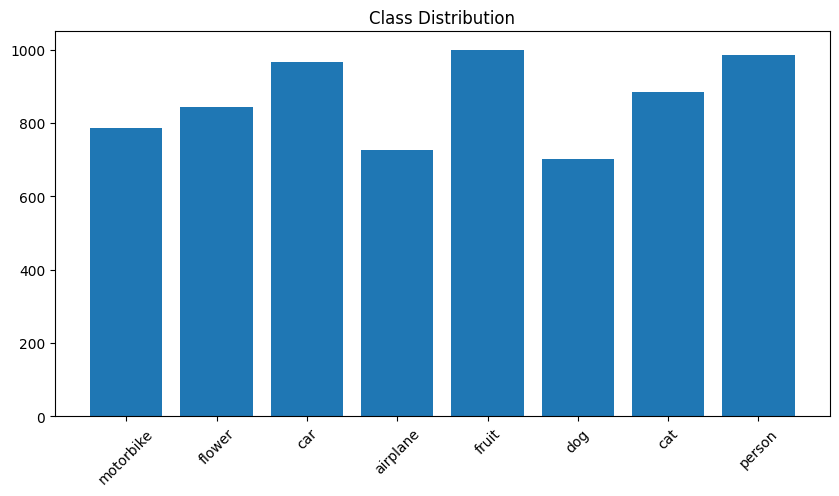

In [14]:
# STEP 4 - CLASS DISTRIBUTION
# ==========================================

image_count = {}

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    image_count[cls] = len(os.listdir(folder))

print(image_count)

plt.figure(figsize=(10,5))
plt.bar(image_count.keys(), image_count.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()


In [15]:
# STEP 5 - DATA PREPROCESSING
# ==========================================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 5522 images belonging to 8 classes.
Found 1377 images belonging to 8 classes.


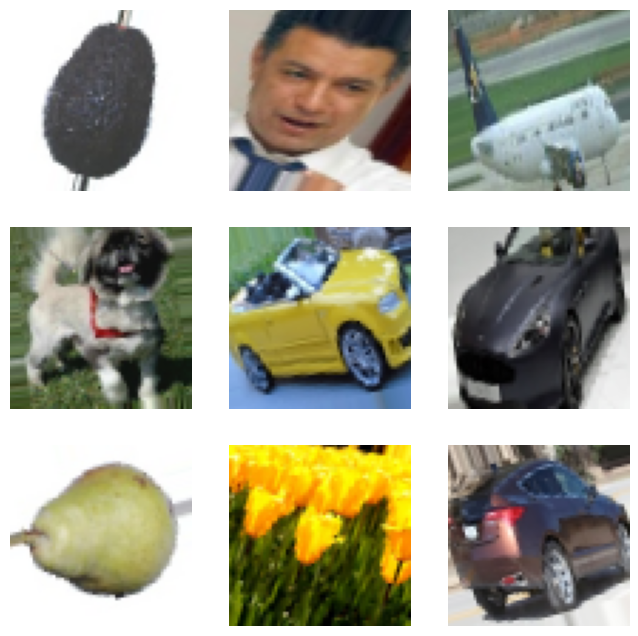

In [16]:
# STEP 6 - SHOW SAMPLE IMAGES
# ==========================================

images, labels = next(train_generator)

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()


In [17]:
# STEP 7 - BASELINE CNN MODEL
# ==========================================

baseline_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(classes), activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 691,976 (2.64 MB)

 Trainable params: 691,976 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# STEP 8 - TRAIN BASELINE MODEL
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3,
    callbacks=[early_stop]
)

Epoch 1/3
346/346 ━━━━━━━━━━━━━━━━━━━━ 58s 162ms/step - accuracy: 0.6090 - loss: 1.0304 - val_accuracy: 0.7451 - val_loss: 0.7457
Epoch 2/3
346/346 ━━━━━━━━━━━━━━━━━━━━ 55s 159ms/step - accuracy: 0.8169 - loss: 0.4922 - val_accuracy: 0.8192 - val_loss: 0.4885
Epoch 3/3
346/346 ━━━━━━━━━━━━━━━━━━━━ 54s 155ms/step - accuracy: 0.8502 - loss: 0.4038 - val_accuracy: 0.7959 - val_loss: 0.6032


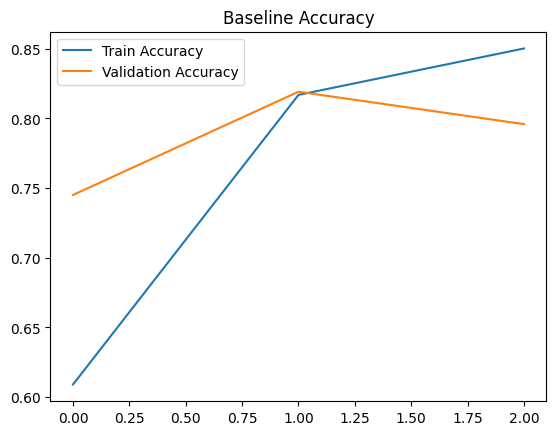

In [19]:
# STEP 9 - ACCURACY GRAPH
# ==========================================

plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Baseline Accuracy")
plt.show()

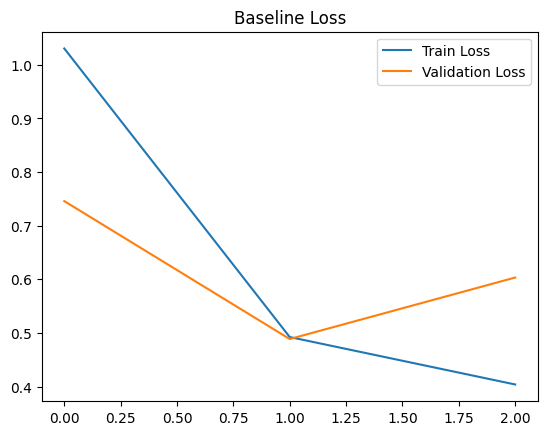

In [21]:
# STEP 10 - LOSS GRAPH
# ==========================================

plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Baseline Loss")
plt.show()

In [22]:
# STEP 11 - EVALUATION
# ==========================================

predictions = baseline_model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

print(classification_report(true_classes, predicted_classes))

87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step
              precision    recall  f1-score   support

           0       0.07      0.04      0.05       145
           1       0.16      0.16      0.16       193
           2       0.09      0.12      0.10       177
           3       0.12      0.15      0.13       140
           4       0.10      0.10      0.10       168
           5       0.16      0.16      0.16       200
           6       0.10      0.10      0.10       157
           7       0.10      0.10      0.10       197

    accuracy                           0.12      1377
   macro avg       0.11      0.11      0.11      1377
weighted avg       0.12      0.12      0.12      1377



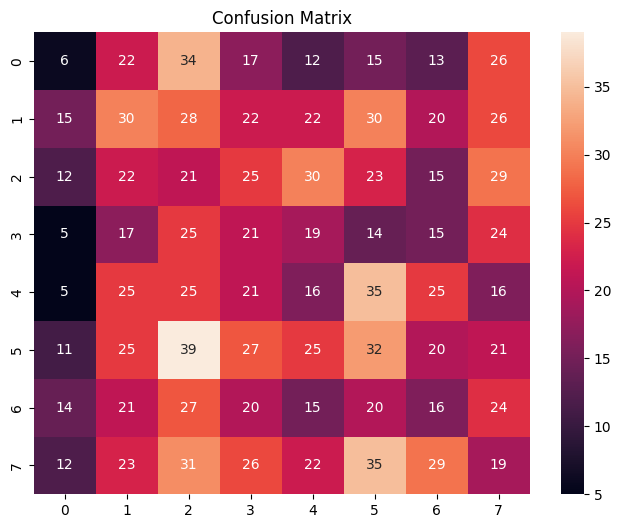

In [23]:
# STEP 12 - CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.show()


In [24]:
# STEP 13 - TRANSFER LEARNING
# ==========================================

base_model = MobileNetV2(
    input_shape=(64,64,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

transfer_model = Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(len(classes), activation='softmax')
])

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

/tmp/ipykernel_15057/3117360107.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

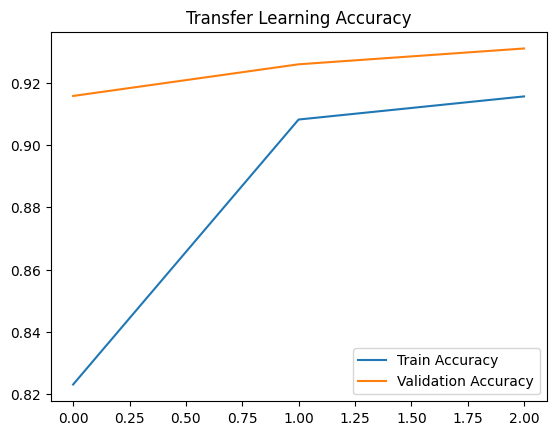

In [25]:
# STEP 15 - TRANSFER LEARNING GRAPH
# ==========================================

plt.plot(history_transfer.history['accuracy'], label='Train Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Transfer Learning Accuracy")
plt.show()

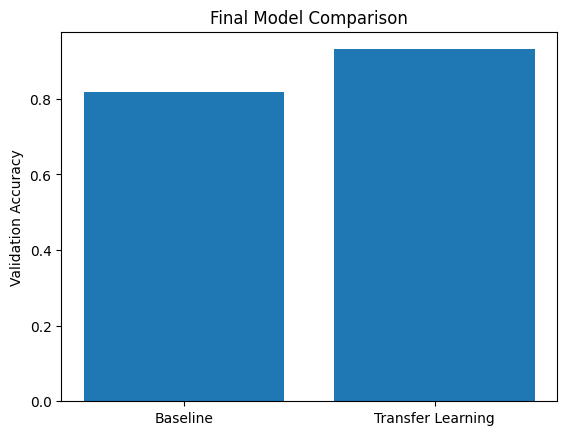

In [26]:
# STEP 16 - FINAL COMPARISON
# ==========================================

models = ['Baseline', 'Transfer Learning']

accuracies = [
    max(history_baseline.history['val_accuracy']),
    max(history_transfer.history['val_accuracy'])
]

plt.bar(models, accuracies)

plt.title("Final Model Comparison")

plt.ylabel("Validation Accuracy")

plt.show()


In [27]:
# STEP 17 - FINAL PREDICTIONS
# ==========================================

transfer_predictions = transfer_model.predict(validation_generator)

transfer_pred_classes = np.argmax(transfer_predictions, axis=1)

print(classification_report(true_classes, transfer_pred_classes))

print("VISION TASK COMPLETED SUCCESSFULLY")

87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step
              precision    recall  f1-score   support

           0       0.75      0.02      0.04       145
           1       0.12      0.04      0.06       193
           2       0.13      0.47      0.21       177
           3       0.05      0.01      0.02       140
           4       0.12      0.32      0.17       168
           5       0.00      0.00      0.00       200
           6       0.14      0.01      0.01       157
           7       0.16      0.15      0.16       197

    accuracy                           0.13      1377
   macro avg       0.18      0.13      0.08      1377
weighted avg       0.17      0.13      0.09      1377

VISION TASK COMPLETED SUCCESSFULLY
